##**Load Data**

In [0]:
# config
storage_account = "lab94290"  
container = "airbnb"

sas_token=""
sas_token = sas_token.lstrip('?')
spark.conf.set(f"fs.azure.account.auth.type.{storage_account}.dfs.core.windows.net", "SAS")
spark.conf.set(f"fs.azure.sas.token.provider.type.{storage_account}.dfs.core.windows.net", "org.apache.hadoop.fs.azurebfs.sas.FixedSASTokenProvider")
spark.conf.set(f"fs.azure.sas.fixed.token.{storage_account}.dfs.core.windows.net", sas_token)

In [0]:
path = f"abfss://{container}@{storage_account}.dfs.core.windows.net/airbnb_1_12_parquet"
airbnb_df = spark.read.parquet(path)

In [0]:
import pyspark.sql.functions as F
from pyspark.sql.functions import col, from_json ,split, count, to_timestamp, month, lit, year, expr
from pyspark.sql.types import MapType, StringType

#Extract location details and parse pricing JSON
airbnb_df = airbnb_df.withColumn("city", F.split(col('location'), ',').getItem(0)) \
                     .withColumn("country", F.element_at(F.split(col('location'), ','), -1)) \
                     .withColumn("num_of_nights", from_json(col("pricing_details"), MapType(StringType(), StringType())).getItem("num_of_nights"))

##**Filter 100 cities and 2025**

In [0]:
from pyspark.sql.functions import col, from_json, to_timestamp, month, year , expr, lit, split, count
from pyspark.sql.types import MapType, StringType

#Filter to Top 100 Cities
data_loc = airbnb_df.select('property_id','city')
top_100 = data_loc.groupBy('city').count().orderBy('count', ascending=False).limit(100)
airbnb_top_100 = airbnb_df.filter(col('city').isin([r['city'] for r in top_100.select('city').collect()]))

#Parse JSON & Extract Date Features
airbnb_top_100 = airbnb_top_100.withColumn("travel_map", from_json(col("travel_details"), MapType(StringType(), StringType()))) \
    .withColumn("check_in", col("travel_map").getItem("check_in")) \
    .withColumn("check_out", col("travel_map").getItem("check_out")) \
    .filter(col("check_in").isNotNull() & col("check_out").isNotNull() & col("num_of_nights").isNotNull()) \
    .withColumn("month", month(to_timestamp(col("check_in")))) \
    .withColumn("year", year(to_timestamp(col("check_in"))))

#Filter for Target Year
airbnb_top_100_25 = airbnb_top_100.filter(col("year") == 2025)

display(airbnb_top_100_25.orderBy(col('property_id')).limit(100))
print(airbnb_top_100_25.count())

name price image description category availability discount reviews ratings seller_info breadcrumbs location lat long guests pets_allowed description_items category_rating house_rules details highlights arrangement_details amenities images available_dates url final_url listing_title property_id listing_name location_details description_by_sections description_html location_details_html is_supperhost host_number_of_reviews host_rating hosts_year host_response_rate is_guest_favorite travel_details pricing_details total_price currency cancellation_policy property_number_of_reviews country postcode_map_url host_image host_details city num_of_nights travel_map check_in check_out month year Home in Denver · ★4.76 · 2 bedrooms · 2 beds · 1 bathroom 99 https://a0.muscache.com/pictures/miso/Hosting-1000017711121390675/original/d5dac126-b019-4d0a-a662-bd429ec72518.jpeg Enjoy your stay at our stylish 2 BR, 1 BR home - perfect for group or family trips or digital nomads looking to be near the action but in a quiet and safe neighborhood. There is a well-equipped kitchen, in-house laundry and multiple spaces to relax, plus a dedicated work space. Located just ten minutes to downtown Denver, and only 15 minutes to Red Rocks. Walk/bike to coffee, restaurants, and more on the popular Tennyson strip!The spaceThere is one king bedroom and one queen bedroom - both equipped with closets and dressers. There is a shared bathroom in the hallway with a standing shower (no tub). There are 2 spacious living rooms - one has a full dining table for all of your guests and one has a wrap around sofa, game table and dedicated office space with big screen TV. There is also a full-size washer and dryer to meet your longer stay needs. The kitchen is well stocked with cooking supplies, including an Instant Pot.Guest accessYou have private access to the entire home. NOTE: The upstairs is currently waiting to complete a renovation to turn this home into a larger space for more guests. While you can access part of this space, it is not advertised as part of your stay and some of the spaces are locked. There will be no work performed on this space during any guest's stay.Other things to noteThere is a second guest house located directly behind the main house on this property. You are booking the main house only. Please respect any other guests that are staying in the back guest house. To rent both the main and guest house together, please see our other listings. Stays true null ["Super cute home and welcoming. Excellent location for hopping on the interstate or just staying local.","Great stay! Great location.","Very good and nice","The basement was a little creepy but the rest of the home was great the attic is cool","It was a great stay. A good location in Denver.","Location and house was good, only issue is both couch stinks and are bad","We had a wonderful stay in Kate’s home!","Very nice place to stay. Comfortable bedding, tv was a little hard to understand.","Great host and house","Good place to stay","Why nice place thank you so much","Good place","Nice 2 bedroom house with comfortable beds for our long weekend getaway.","Kate was a great host and her home had everything my family and I needed. Would definitely come back and visit again!","Kate was very responsible and friendly. I highly recommend her place to families with children.","Kate was very helpful. She was quick to respond to questions, and made it easy for us when our schedule changed.","We had a lot going on while in Denver, so having a solid home base was key. Kate’s home served us well! It had plenty of space for two people to work and the internet was fast - was able to hold multiple zoom calls at one time. The home was very clean and well maintained. A real bonus is there was plenty of hot water for several shower back to back. The location was really great too. Tennyson with lots of coffee shops and restaurants is just a walk away. Additionally, Kate was very responsive to any questions we ha

161998


##**Simple EDA**

<Axes: title={'center': 'Ratings Distribution'}, ylabel='Frequency'>

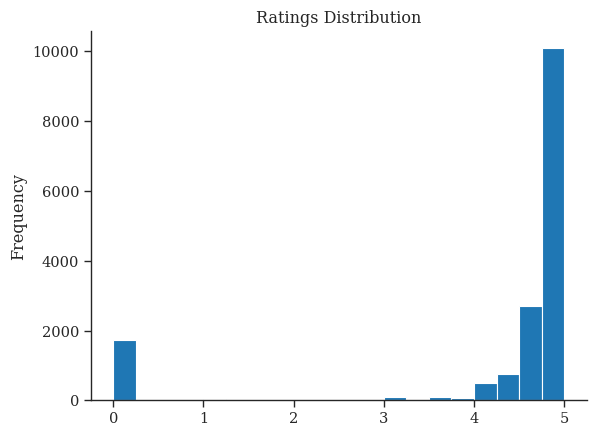

In [0]:
#Sample 10% of the data
sample_df = airbnb_top_100_25.sample(fraction=0.1, seed=42)

#Plot the distribution of 'ratings'
sample_df.select("ratings").toPandas()['ratings'].astype(float).dropna().plot.hist(bins=20, title="Ratings Distribution")


<Axes: title={'center': 'Is Supperhost Distribution'}>

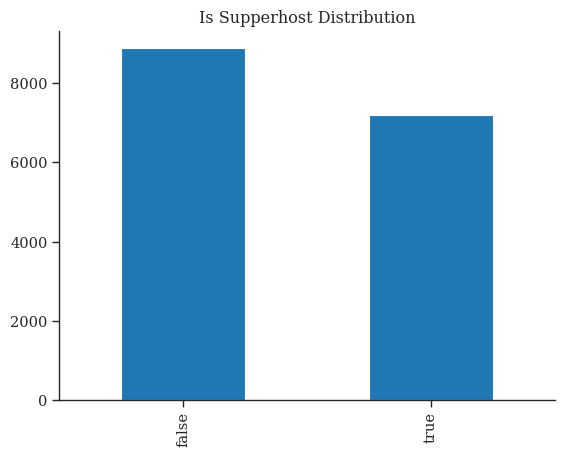

In [0]:
sample_df.select("is_supperhost").toPandas()['is_supperhost'].value_counts().plot.bar(title="Is Supperhost Distribution")

<Axes: title={'center': 'Top 15 Cities by Count'}, xlabel='city'>

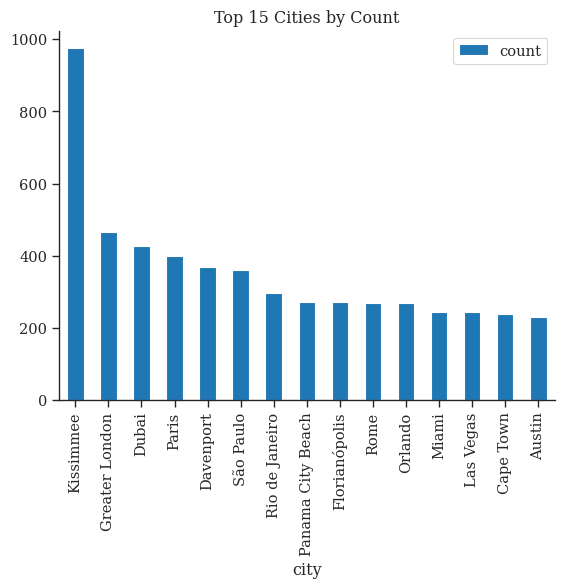

In [0]:
city_counts = sample_df.groupBy("city").count().orderBy(col("count").desc()).limit(15)
city_counts_pd = city_counts.toPandas()
city_counts_pd.plot.bar(x='city', y='count', title="Top 15 Cities by Count")

In [0]:
#Block: Country Code Mapping
from pyspark.sql.functions import create_map, lit, col, trim, regexp_replace
from itertools import chain

#Define Master Dictionary (Name -> ISO Code)
COUNTRY_CODE_MAP = {
    "Colombia": "CO", "Kenya": "KE", "Australia": "AU", "Denmark": "DK", "Canada": "CA",
    "United Arab Emirates": "AE", "Germany": "DE", "South Korea": "KR", "Spain": "ES",
    "Chile": "CL", "Peru": "PE", "Georgia": "GE", "Philippines": "PH", "Malaysia": "MY",
    "Morocco": "MA", "Argentina": "AR", "Netherlands": "NL", "Saudi Arabia": "SA", "Italy": "IT",
    "Brazil": "BR", "Portugal": "PT", "Austria": "AT", "Poland": "PL", "Hungary": "HU",
    "Greece": "GR", "United States": "US", "Venezuela": "VE", "United Kingdom": "GB", "Mexico": "MX",
    "South Africa": "ZA", "France": "FR", "Costa Rica": "CR", "Belize": "BZ", "El Salvador": "SV",
    "Puerto Rico": "PR", "Uruguay": "UY", "Bolivia": "BO", "Nicaragua": "NI", "Honduras": "HN"
}

#Convert to Spark Map Expression
mapping_expr = create_map([lit(x) for x in chain(*COUNTRY_CODE_MAP.items())])

#Apply Mapping (Clean first, then Map)
df_mapped = airbnb_top_100_25.withColumn("clean_country", trim(regexp_replace(col("country"), "\u00A0", ""))) \
                             .withColumn("country_code", mapping_expr[col("clean_country")])

#Validation
print("Rows with Unmapped Countries:")
unmapped_count = df_mapped.filter(col("country_code").isNull()).count()
print(f"Count: {unmapped_count}")

if unmapped_count > 0:
    print("Distinct names that failed mapping:")
    df_mapped.filter(col("country_code").isNull()).select("clean_country").distinct().show(truncate=False)



Rows with Unmapped Countries:
Count: 0


In [0]:
%pip install holidays -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

import holidays
from pyspark.sql.functions import col, explode, sequence, dayofweek, count, date_sub, lit, when, year

def calculate_and_return_occupancy_ratio(df): 
    #Calculates the ratio of booked days between Weekend/Holiday and Normal days.
    daily_df = df.filter(col("check_out") > col("check_in")) \
                 .withColumn("stay_date", explode(sequence(col("check_in").cast("date"), 
                                                           date_sub(col("check_out").cast("date"), 1))))

    #Identify EXTENDED Weekends (Fri=6, Sat=7, Sun=1)
    daily_df = daily_df.withColumn("is_weekend", when(dayofweek(col("stay_date")).isin([6, 7, 1]), 1).otherwise(0))

    #Identify Holidays (Dynamic)
    combos = daily_df.select("country_code", year("stay_date").alias("year")).distinct().collect()
    all_holidays = []
    
    for row in combos:
        try:
            h_dict = holidays.country_holidays(row['country_code'], years=row['year'])
            all_holidays.extend([(d, row['country_code']) for d in h_dict.keys()])
        except: continue

    if all_holidays:
        holidays_df = spark.createDataFrame(all_holidays, ["h_date", "h_country"]).withColumn("is_holiday", lit(1))
        daily_df = daily_df.join(holidays_df, 
                                (daily_df.stay_date == holidays_df.h_date) & 
                                (daily_df.country_code == holidays_df.h_country), "left").na.fill(0, subset=["is_holiday"])
    else:
        daily_df = daily_df.withColumn("is_holiday", lit(0))

    daily_df = daily_df.withColumn("is_premium", when((col("is_weekend") == 1) | (col("is_holiday") == 1), 1).otherwise(0))
    counts = daily_df.groupBy("is_premium").agg(count("*").alias("booked_days")).collect()

    try:
        booked_normal = next(r['booked_days'] for r in counts if r['is_premium'] == 0)
        booked_premium = next(r['booked_days'] for r in counts if r['is_premium'] == 1)
        
        ratio = (booked_premium / 3.0) / (booked_normal / 4.0)
        print(f"Occupancy Analysis: Normal={booked_normal}, Premium={booked_premium} -> Ratio: {ratio:.2f}x")
        return ratio
    except:
        print("Insufficient data for ratio. Defaulting to 1.0")
        return 1.0

OCCUPANCY_RATIO = calculate_and_return_occupancy_ratio(df_mapped)

Occupancy Analysis: Normal=304976, Premium=257335 -> Ratio: 1.13x


##**Calculate price per person**

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import MapType, StringType

#Parse the JSON string into a Map and extract the specific key as a double
airbnb_top_100_25 = (
    airbnb_top_100_25
    .withColumn("pricing_details_map", F.from_json(F.col("pricing_details"), MapType(StringType(), StringType())))
    .withColumn("base_price_per_night", F.col("pricing_details_map")["price_per_night"].cast("double"))
)

#Validation: Check for nulls generated by the casting or missing keys
null_count = airbnb_top_100_25.filter(F.col("base_price_per_night").isNull()).count()
print(f"Number of rows with null 'base_price_per_night': {null_count}")



Number of rows with null 'base_price_per_night': 0


In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

#Constants
EUR_TO_USD = 1.1

#Define Window specification
w_country = Window.partitionBy("country")

airbnb_top_100_25 = (
    airbnb_top_100_25
    #Determine effective currency: Use existing currency then fallback to country average then fallback to EUR
    .withColumn(
        "effective_currency",
        F.coalesce(
            F.col("currency"), 
            F.first("currency", ignorenulls=True).over(w_country), 
            F.lit("EUR")
        )
    )
    #Normalize price to USD
    .withColumn(
        "price_per_night",
        F.when(F.col("effective_currency") == "EUR", F.col("base_price_per_night") * EUR_TO_USD)
         .otherwise(F.col("base_price_per_night"))
    )
)

display(airbnb_top_100_25.limit(1))

name,price,image,description,category,availability,discount,reviews,ratings,seller_info,breadcrumbs,location,lat,long,guests,pets_allowed,description_items,category_rating,house_rules,details,highlights,arrangement_details,amenities,images,available_dates,url,final_url,listing_title,property_id,listing_name,location_details,description_by_sections,description_html,location_details_html,is_supperhost,host_number_of_reviews,host_rating,hosts_year,host_response_rate,is_guest_favorite,travel_details,pricing_details,total_price,currency,cancellation_policy,property_number_of_reviews,country,postcode_map_url,host_image,host_details,city,num_of_nights,travel_map,check_in,check_out,month,year,pricing_details_map,base_price_per_night,effective_currency,price_per_night
Rental unit in Miami · ★New · 2 bedrooms · 3 beds · 2 baths,137,https://a0.muscache.com/pictures/miso/Hosting-1356171855811707125/original/f4736f9c-cc9c-4693-b029-546c5e09c523.jpeg,"Magic Mountain is an iconic 4.5 star holiday and permanent residential complex situated between Coolangatta and Surfers Paradise.You are located at Nobby Beach/Miami a trendy seaside township which offers great restaurants, cafes, bars and beaches. Enjoy easy access to everything from this centrally located place.Relax in this stylish 2 bedroom 2 bathroom apartment in walking distance to the beach.The spaceThe master bedroom with king bed is complete with a walk in robe and ensuited bathroom, the bedroom opens up to a balcony. Second bedroom has 2 single beds with separate bathroom.A fully functioning kitchen, airy dining room and lounge area provides comfortable seating, TV and balcony and access to the second bathroom.The apartment also has a great patio that provides seating and dining options.This is a non-smoking apartment.Guest accessThe complex facilities include lush tropical gardens that run through the entire complex, there are three styled pools including the Lagoon Pool with sand and Rock Spa, the Heated Rock Pool and the Infinity Pool and Heated Spa which offers the best views the Gold Coast has to offer.There is a fully equipped gym, new sauna, BBQ Area all amongst a secured gated complex.Not suitable for clients with mobility issues.Other things to notePlease note the property is not suited to wheel chairs or those with mobility issues.This is a non-smoking complex.",Stays,true,null,null,0,"{""seller_id"":""475507905"",""url"":""https://www.airbnb.com/users/show/475507905""}","Miami, Queensland, Australia","Miami, Queensland, Australia",-28.0616,153.4397,4,false,"[""Entire rental unit"",""3 beds"",""2 baths""]",[],"[""Check-in after 2:00 p.m."",""Checkout before 10:00 a.m."",""4 guests maximum""]","[""4 guests"",""2 bedrooms"",""3 beds"",""2 baths""]","[{""name"":""Dive right in"",""value"":""This is one of the few places in the area with a pool.""},{""name"":""Self check-in"",""value"":""You can check in with the building staff.""},{""name"":""Great Host communication"",""value"":""Recent guests loved David's communication.""}]",null,"[{""group_name"":""Bathroom"",""items"":[{""name"":""Hot water"",""value"":""SYSTEM_HOT_WATER""}]},{""group_name"":""Bedroom and laundry"",""items"":[{""name"":""Washer"",""value"":""SYSTEM_WASHER""},{""name"":""Free dryer – In unit"",""value"":""SYSTEM_DRYER""},{""name"":""Bed linens"",""value"":""SYSTEM_BLANKETS""},{""name"":""Clothing storage: walk-in closet and wardrobe"",""value"":""SYSTEM_WARDROBE""}]},{""group_name"":""Entertainment"",""items"":[{""name"":""TV"",""value"":""SYSTEM_TV""},{""name"":""Exercise equipment"",""value"":""SYSTEM_GYM""}]},{""group_name"":""Heating and cooling"",""items"":[{""name"":""Air conditioning"",""value"":""SYSTEM_SNOWFLAKE""}]},{""group_name"":""Home safety"",""items"":[{""name"":""Exterior security cameras on property"",""value"":""Security cameras are located throughout the complex""},{""name"":""Smoke alarm"",""value"":""SYSTEM_DETECTOR_SMOKE""}]},{""group_name"":""Internet and office"",""items"":[{""name

##**Amenities score**

In [0]:
import json
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

def count_amenities_logic(amenities_str):
    #Parses JSON and counts items, excluding 'Not included' groups.
    if not amenities_str:
        return 0
    try:
        data = json.loads(amenities_str)
        #Sum the length of items for valid groups only
        return sum(
            len(group.get('items', [])) 
            for group in data 
            if group.get('group_name') != "Not included")
    except (ValueError, TypeError, json.JSONDecodeError):
        return 0

#Register the UDF
count_amenities_udf = F.udf(count_amenities_logic, IntegerType())

#Apply transformation
airbnb_top_100_25 = airbnb_top_100_25.withColumn(
    "amenities_score", 
    F.log1p(count_amenities_udf(F.col("amenities"))))

display(airbnb_top_100_25.limit(1))

name,price,image,description,category,availability,discount,reviews,ratings,seller_info,breadcrumbs,location,lat,long,guests,pets_allowed,description_items,category_rating,house_rules,details,highlights,arrangement_details,amenities,images,available_dates,url,final_url,listing_title,property_id,listing_name,location_details,description_by_sections,description_html,location_details_html,is_supperhost,host_number_of_reviews,host_rating,hosts_year,host_response_rate,is_guest_favorite,travel_details,pricing_details,total_price,currency,cancellation_policy,property_number_of_reviews,country,postcode_map_url,host_image,host_details,city,num_of_nights,travel_map,check_in,check_out,month,year,pricing_details_map,base_price_per_night,effective_currency,price_per_night,amenities_score
Home in Brooklyn · ★4.64 · 1 bedroom · 1 bed · 1 private bath,40.01,https://a0.muscache.com/pictures/miso/Hosting-1179684682147960268/original/ca0a0a4e-dbae-45aa-b684-ef45e153786a.png,"Brand new house:- Modern simplistic house- High-speed wifi - 26 km to Airport and 13 km to Melbourne CBD- Fully furnished: Queen Bed, Wardrobe, Smart TV ( free Netflix)- Bus to Train station ( from 1 block away)- Free on-site parking and Safe street parking- Dimmable lights, lockable room- Fresh towels, and fresh linen/blanketsTo City?19-20 minutes by taxi Supermarket?Altona Gate SC - 15-20 mins walkHighpoint - 12 min taxiLate-night snacks?- Kebab/ Pizza shop 5 minutes walk",Stays,true,null,"[""Great stay with Kunal and his partner. The room and bathroom were clean and comfortable. Closest bus stop to get to Melbourne city was 10-20 minutes, depending on where you are going. Walking distance to plaza with Coles, Aldis was 20 minutes walking. The property was well maintained and comfortable. Thank you for a great stay!"",""Great location for work when I travel from interstate. Lovely and peaceful room and house. Kunal was a great host. Close enough to Coles (supermarket) to walk. Will make it a regular returning location"",""Great place to stay and Kunal and his partner were wonderful hosts. Very attentive and full of advice."",""Kunal's place is lovely and absolutely value for money. He is very responsive. Would love to stay again."",""Kunal was helpful and friendly and his place is very central and perfect for what we needed."",""Fantastic stop over with great hosts"",""Host and place are just perfect."",""It was different from the photos, and there was dust and vacuum cleaner parts under the bed, and there was so much dust such as the bottom of the bed frame that my throat hurt. In addition, I made them wait at the door without sending check-in instructions in advance. There were a lot of disappointments."",""Great"",""Nice,clean and cozy house.🤍🤍"",""Kunal is adorable and very helpful, I felt comfortable and safe in this Airbnb. It is very well located, there is a shopping center 15 min walk away and full of public transport that allow you to go to the city center.""]",4.64,"{""seller_id"":""278489753"",""url"":""https://www.airbnb.com/users/show/278489753""}","Brooklyn, Victoria, Australia","Brooklyn, Victoria, Australia",-37.81767,144.84578,1,null,"[""Private room in home"",""1 bed"",""1 private bath""]","[{""name"":""Cleanliness"",""value"":""4.5""},{""name"":""Accuracy"",""value"":""4.6""},{""name"":""Check-in"",""value"":""4.7""},{""name"":""Communication"",""value"":""4.7""},{""name"":""Location"",""value"":""4.5""},{""name"":""Value"",""value"":""4.6""}]","[""Check-in after 1:00 PM"",""Checkout before 10:00 AM"",""1 guest maximum""]","[""1 bed"",""Dedicated bathroom""]","[{""name"":""Self check-in"",""value"":""Check yourself in with the keypad.""},{""name"":""Great host communication"",""value"":""Recent guests loved Kunal's communication.""},{""name"":""Room in a home"",""value"":""Your own room in a home, plus access to shared spaces.""}]",null,"[{""group_name"":""Bathroom"",""items"":[{""name"":""Hair dryer"",""value"":""SYSTEM_HAIRDRYER""},{""name"":""Cleaning

##**Aggregate monthly**

In [0]:
from pyspark.sql import functions as F

months_df = spark.range(1, 13).toDF("month")

#Calculate actual stats per property/month
property_month_stats = (
    airbnb_top_100_25
    .groupBy("property_id", "month")
    .agg(F.sum("num_of_nights").alias("calc_days"))
)

#This ensures every property has a row for every month (1-12)
property_months = (
    airbnb_top_100_25.select("property_id").distinct()
    .crossJoin(months_df))

#Join actual stats to the backbone, fill gaps with 0, and cap at 31
result = (
    property_months
    .join(property_month_stats, on=["property_id", "month"], how="left")
    .na.fill(0, subset=["calc_days"])
    .withColumn("num_days", F.least(F.col("calc_days"), F.lit(31))) # Efficiently caps value at 31
    .drop("calc_days")
    .orderBy("property_id", "month"))

display(result.limit(12))

property_id,month,num_days
1000017711121390675,1,0.0
1000017711121390675,2,2.0
1000017711121390675,3,0.0
1000017711121390675,4,0.0
1000017711121390675,5,0.0
1000017711121390675,6,0.0
1000017711121390675,7,0.0
1000017711121390675,8,0.0
1000017711121390675,9,0.0
1000017711121390675,10,0.0


In [0]:
feature_cols = [
    "property_id", "city", "ratings", "year", "is_supperhost", 
    "host_rating", "property_number_of_reviews", "price_per_night", 
    "guests", "amenities_score", "description_items"]

property_data = (
    airbnb_top_100_25
    .dropDuplicates(["property_id"])
    .select(*feature_cols))

final = result.join(property_data, on="property_id", how="left")

model_data = final.select("property_id", "month", "num_days")
display(final.orderBy("property_id", "month").limit(24))

property_id,month,num_days,city,ratings,year,is_supperhost,host_rating,property_number_of_reviews,price_per_night,guests,amenities_score,description_items
1000017711121390675,1,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,2,2.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,3,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,4,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,5,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,6,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,7,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,8,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,9,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,10,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"


##**Predict future months**

In [0]:
!pip install pytrends -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
from pytrends.request import TrendReq

#Initialize and fetch weekly data
pytrends = TrendReq(hl='en-US', tz=360)
kw_list = ["Airbnb"]
pytrends.build_payload(kw_list, cat=0, timeframe="2025-01-01 2025-12-31", geo="")
df_weekly = pytrends.interest_over_time()
# This ensures we have a value for every single day before averaging
daily_index = pd.date_range(start="2025-01-01", end="2025-12-31", freq='D')
df_daily = df_weekly.reindex(daily_index, method='ffill')
#Aggregate to monthly averages
df_monthly_accurate = df_daily.resample('MS').mean()

#Cleanup
if 'isPartial' in df_monthly_accurate.columns:
    df_monthly_accurate = df_monthly_accurate.drop(columns=['isPartial'])

display(df_monthly_accurate)

Airbnb
81.0
76.03571428571429
76.51612903225806
77.33333333333333
79.80645161290323
85.43333333333334
90.09677419354838
93.16129032258064
78.23333333333333
74.96774193548387


In [0]:
import pandas as pd
import numpy as np
#SETUP: LOAD & CLEAN DATA
df_raw = model_data.toPandas()
# FIX: Drop exact duplicates
df_raw = df_raw.drop_duplicates(subset=['property_id', 'month'])
#Rename & Format
df_raw = df_raw.rename(columns={'property_id': 'ID', 'month': 'Month', 'num_days': 'Amount'})
df_raw['Month'] = df_raw['Month'].astype(int)
df_raw['Date'] = pd.to_datetime('2025-' + df_raw['Month'].astype(str) + '-01')
#PREPARE TRENDS & AGGREGATE
df_trends_clean = df_monthly_accurate[['Airbnb']].copy()
df_trends_clean.columns = ['Trend_Score']
df_trends_clean.index = pd.to_datetime(df_trends_clean.index)
df_monthly_internal = df_raw.groupby('Date')['Amount'].sum().reset_index()
df_monthly_internal.columns = ['Date', 'Actual_Total']
df_monthly_internal.set_index('Date', inplace=True)
df_merged = df_monthly_internal.join(df_trends_clean, how='inner')
#PREDICT TARGET TOTALS
baseline_mask = (df_merged.index.month <= 8) & (df_merged.index.month != 6) & (df_merged.index.month != 4)
avg_trend = df_merged.loc[baseline_mask, 'Trend_Score'].mean()
avg_vol = df_merged.loc[baseline_mask, 'Actual_Total'].mean()
ratio = avg_vol / avg_trend
#Predict (Months 9-12 only)
df_merged['Predicted_Total'] = np.where(
    df_merged.index.month <= 8,
    df_merged['Actual_Total'],
    df_merged['Trend_Score'] * ratio)
#Calculate Missing Pot
df_merged['Missing_Volume_To_Allocate'] = (df_merged['Predicted_Total'] - df_merged['Actual_Total']).clip(lower=0)
#CALCULATE ADJUSTED WEIGHTS
reliable_df = df_raw[df_raw['Month'] <= 8]
total_reliable_volume = reliable_df['Amount'].sum()
id_weights = reliable_df.groupby('ID')['Amount'].sum() / total_reliable_volume
df_weights = id_weights.reset_index(name='Base_Weight')
#Merge
df_final = df_raw.merge(df_weights, on='ID', how='left')
df_final['Base_Weight'] = df_final['Base_Weight'].fillna(0)
median_weight = df_final[df_final['Base_Weight'] > 0]['Base_Weight'].median()
df_final['Base_Weight'] = df_final['Base_Weight'].replace(0, median_weight)
#Re Normalize Weights (Sum = 1.0)
monthly_weight_sums = df_final.groupby('Month')['Base_Weight'].transform('sum')
df_final['Adjusted_Weight'] = df_final['Base_Weight'] / monthly_weight_sums
df_pot = df_merged[['Missing_Volume_To_Allocate']].copy()
df_pot['Month'] = df_pot.index.month.astype(int)
df_final = df_final.merge(df_pot, on='Month', how='left')
df_final['Allocated_Amount'] = df_final['Missing_Volume_To_Allocate'] * df_final['Adjusted_Weight']
df_final['Allocated_Amount'] = df_final['Allocated_Amount'].fillna(0)
df_final['Final_Float'] = df_final['Amount'] + df_final['Allocated_Amount']

def smart_round_group(group):    
    if group['Month'].iloc[0] < 9:
        return group['Final_Float'].astype(int)
    floored = np.floor(group['Final_Float']).astype(int)
    target_sum = int(group['Final_Float'].sum()) 
    current_sum = floored.sum()
    shortage = target_sum - current_sum
    remainders = group['Final_Float'] - floored
    
    if shortage > 0:
        top_indices = remainders.argsort().values[-shortage:]
        #Add +1 to those specific rows
        floored.iloc[top_indices] += 1
       
    return floored

#Apply the function per month
df_final['Final_Predicted_Amount'] = df_final.groupby('Month').apply(smart_round_group).reset_index(level=0, drop=True)
#FINAL VALIDATION
final_output = df_final[['ID', 'Month', 'Final_Predicted_Amount']]

print("\n--- Validation: Does New Sum match Prediction? ---")
check = final_output.groupby('Month')['Final_Predicted_Amount'].sum().reset_index()
check.columns = ['Month', 'New_Sum']

check['Target'] = check['Month'].map(
    lambda m: int(df_merged.loc[df_merged.index.month == m, 'Predicted_Total'].values[0]))
check['Difference'] = check['New_Sum'] - check['Target']

display(check)


--- Validation: Does New Sum match Prediction? ---


Month,New_Sum,Target,Difference
1,35744,35744,0
2,24115,24115,0
3,54516,54516,0
4,141397,141397,0
5,36568,36568,0
6,123873,123873,0
7,42376,42376,0
8,30616,30616,0
9,35277,35277,0
10,33804,33804,0


In [0]:
from pyspark.sql.functions import col, when


predictions_spark = spark.createDataFrame(final_output)

predictions_spark = predictions_spark.select(
    col("ID").alias("property_id"),
    col("Month").alias("month"),
    col("Final_Predicted_Amount").alias("new_num_days"))

#Join with the large 'final' dataset
df_merged_spark = final.join(
    predictions_spark, 
    on=["property_id", "month"], 
    how="left")

#Update the 'num_days' column
#Logic: If 'new_num_days' is NOT null, use it. Otherwise, keep original 'num_days'.
df_updated = df_merged_spark.withColumn(
    "num_days",
    when(col("new_num_days").isNotNull(), col("new_num_days")).otherwise(col("num_days")))

#Drop the temporary column
df_updated = df_updated.drop("new_num_days")

#Verify and Show
#Now we can just show a few rows without crashing the memory
print(f"Total Rows: {df_updated.count()}")
display(df_updated.orderBy("property_id","month").limit(10))

Total Rows: 1736220


property_id,month,num_days,city,ratings,year,is_supperhost,host_rating,property_number_of_reviews,price_per_night,guests,amenities_score,description_items
1000017711121390675,1,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,2,2.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,3,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,4,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,5,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,6,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,7,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,8,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,9,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"
1000017711121390675,10,0.0,Denver,4.76,2025,false,4.76,null,99.0,4,3.828641396489095,"[""Entire home"",""2 beds"",""1 bathroom""]"


##**Add Numbeo data**

In [0]:
#Filter out cities with missing data from Numbeo
df_filter = df_updated.filter(((col('city') != 'Davenport') & (col('city')!= 'Centro') &
(col('city')!= 'Park City') & (col('city') != 'Truckee') & (col('city') != 'Denver') &
(col('city') != 'Rio de Janeiro')))


In [0]:
# sas_token_external =""

# spark.conf.set(f"fs.azure.account.auth.type.{storage_account}.dfs.core.windows.net", "SAS")
# spark.conf.set(f"fs.azure.sas.token.provider.type.{storage_account}.dfs.core.windows.net", "org.apache.hadoop.fs.azurebfs.sas.FixedSASTokenProvider")
# spark.conf.set(f"fs.azure.sas.fixed.token.{storage_account}.dfs.core.windows.net", sas_token_external)
# file_name_NB = "NumbeoData.csv"

# path = f"abfss://submissions@lab94290.dfs.core.windows.net/yuval_yuval_ofek/Numbeo/{file_name_NB}"
# df_economical = (spark.read
#                  .option("header", "true")
#                  .option("inferSchema", "true")
#                  .option("quote", "\"")      # Handles the wrapping quotes
#                  .option("escape", "\"")     # Handles the "" inside the JSON
#                  .option("multiLine", "true") # Essential for complex CSVs
#                  .csv(path))

# display(df_economical)


In [0]:
from pyspark.sql.functions import col, create_map, lit, coalesce, trim, from_json
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from itertools import chain

#City Mapping Dictionary
city_map_dict = {
    "Kissimmee": "Kissimmee-FL-United-States", "Paris": "Paris", "Greater London": "London",
    "Rome": "Rome", "Dubai": "Dubai", "San Francisco": "San-Francisco",
    "São Paulo": "Sao-Paulo", "Los Angeles": "Los-Angeles", "Rio de Janeiro": "Rio-de-Janeiro",
    "New York": "New-York", "Davenport": "Davenport-FL-United-States", "Las Vegas": "Las-Vegas",
    "Brooklyn": "Brooklyn", "Toronto": "Toronto", "Austin": "Austin",
    "Madrid": "Madrid", "Miami": "Miami", "Lahaina": "Honolulu",
    "Cape Town": "Cape-Town", "San Diego": "San-Diego", "Mexico City": "Mexico-City",
    "Kuala Lumpur": "Kuala-Lumpur", "Buenos Aires": "Buenos-Aires", "Houston": "Houston",
    "Florianópolis": "Florianopolis", "Kihei": "Honolulu", "Orlando": "Orlando",
    "Panama City Beach": "Panama-City-FL", "Seattle": "Seattle", "Nashville": "Nashville",
    "Copenhagen": "Copenhagen", "Atlanta": "Atlanta", "Barcelona": "Barcelona",
    "Naples": "Naples", "Athens": "Athens", "Milan": "Milan",
    "Medellín": "Medellin", "Myrtle Beach": "Myrtle-Beach", "Nice": "Nice",
    "Lisbon": "Lisbon", "Bogotá": "Bogota", "Florence": "Florence",
    "Destin": "Destin-Fl-United-States", "Málaga": "Malaga", "Dallas": "Dallas",
    "Riyadh": "Riyadh", "Budapest": "Budapest", "Sevierville": "Knoxville",
    "Marseille": "Marseille", "Chicago": "Chicago", "Washington": "Washington",
    "South Lake Tahoe": "San-Francisco", "Scottsdale": "Scottsdale", "Porto": "Porto",
    "Honolulu": "Honolulu", "Phoenix": "Phoenix", "Seoul": "Seoul",
    "San Antonio": "San-Antonio", "Vienna": "Vienna", "New Orleans": "New-Orleans",
    "Playa del Carmen": "Playa-del-Carmen", "Denver": "Denver-Australia",
    "Miramar Beach": "Destin-Fl-United-States", "Cannes": "Cannes-France",
    "Marrakesh": "Marrakech", "Portland": "Portland", "Venice": "Venice",
    "Tampa": "Tampa", "Berlin": "Berlin", "Centro": "El-Centro-CA-United-States",
    "Hilton Head Island": "Hilton-Head-Island-SC-United-States",
    "Park City": "Park-City-UT-United-States", "Oakland": "Oakland",
    "Ocean City": "Rehoboth-Beach-DE-United-States", "Amsterdam": "Amsterdam",
    "Breckenridge": "Breckenridge-CO-United-States", "Athina": "Athens",
    "Gulf Shores": "Niceville-FL-United-States", "Santa Rosa Beach": "Fort-Walton-Beach-FL-United-States",
    "Ubatuba": "Ubatuba-Brazil", "Palm Springs": "Palm-Springs", "Warsaw": "Warsaw",
    "Palermo": "Palermo", "Marbella": "Marbella", "Cape Coral": "Cape-Coral-FL-United-States",
    "Tulum": "Tulum-Mexico", "Tucson": "Tucson", "Truckee": "Truckee-CA-United-States",
    "Miami Beach": "Miami", "Philadelphia": "Philadelphia", "Orange Beach": "Destin-Fl-United-States",
    "Fort Lauderdale": "Fort-Lauderdale", "Queens": "Queens", "Praia Grande": "Praia-Grande-Brazil",
    "Kraków": "Krakow-Cracow", "North Myrtle Beach": "Niceville-FL-United-States",
    "Nairobi": "Nairobi", "Tbilisi": "Tbilisi", "Hollywood": "Hollywood-FL",
    "St. Augustine": "Jacksonville"
}

# Transform dict to Spark mapping expression
mapping_expr = create_map([lit(x) for x in chain(*city_map_dict.items())])

csv_file_path = "file:/Workspace/Users/yuval.shanie@campus.technion.ac.il/Drafts/numbeo_dataset.csv"


df_economical = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .load(csv_file_path)

# Data Preparation
json_schema = StructType([
    StructField("value", DoubleType(), True),
    StructField("currency", StringType(), True),
    StructField("symbol", StringType(), True)
])

# Process the Economical Data (Source for joining)
df_economical_clean = df_economical.withColumn(
    "city_name", trim(col("city_name"))
).withColumn(
    "salary_struct", from_json(col("average_monthly_net_salary"), json_schema)
).select(
    col("city_name"),
    col("price_to_rent_ratio_city_centre"),
    col("price_to_rent_ratio_outside_centre"),
    col("salary_struct.value").alias("avg_salary_value"),
    col("salary_struct.currency").alias("avg_salary_currency")
)

# Mapping and Joining 
# Map local city names to Numbeo keys
df_mapped = df_filter.withColumn(
    "external_city_key", 
    mapping_expr.getItem(trim(col("city")))
)

# Join datasets
df_joined = df_mapped.join(
    df_economical_clean,
    df_mapped["external_city_key"] == df_economical_clean["city_name"],
    "left"
)

# Final Cleanup
new_cols = [
    "price_to_rent_ratio_city_centre", 
    "price_to_rent_ratio_outside_centre", 
    "avg_salary_value",
    "avg_salary_currency"
]

# Fill nulls with "unknown" (Note: this casts numeric columns to String)
for column_name in new_cols:
    df_joined = df_joined.withColumn(
        column_name, 
        coalesce(col(column_name).cast("string"), lit("unknown"))
    )

df_numbeo = df_joined.drop("external_city_key", "city_name")

display(df_numbeo.sort('property_id', 'month').limit(1))

/databricks/spark/python/pyspark/sql/column.py:486: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


property_id,month,num_days,city,ratings,year,is_supperhost,host_rating,property_number_of_reviews,price_per_night,guests,amenities_score,description_items,price_to_rent_ratio_city_centre,price_to_rent_ratio_outside_centre,avg_salary_value,avg_salary_currency
1000035369775913721,1,0.0,Florianópolis,0,2025,false,0,0,131.0,4,2.639057329615259,"[""Entire home"",""2 beds"",""2 baths""]",20.78,18.22,3972.82,BRL


In [0]:
from pyspark.sql.functions import col, when, round, lit

# Define Exchange Rates (Local Currency to USD)
exchange_rates = {
    "USD": 1.0,
    "EUR": 1.09,      # Euro
    "GBP": 1.27,      # British Pound
    "AED": 0.27,      # UAE Dirham
    "BRL": 0.20,      # Brazilian Real
    "COP": 0.00025,   # Colombian Peso
    "GEL": 0.37,      # Georgian Lari
    "HUF": 0.0028,    # Hungarian Forint
    "IRR": 0.000024,  # Iranian Rial
    "KES": 0.0063,    # Kenyan Shilling
    "KSh": 0.0063,    # Kenyan Shilling (Alt)
    "KRW": 0.00075,   # South Korean Won
    "MAD": 0.10,      # Moroccan Dirham
    "MXN": 0.058,     # Mexican Peso
    "MYR": 0.21,      # Malaysian Ringgit
    "NIO": 0.027,     # Nicaraguan Córdoba
    "PLN": 0.25,      # Polish Zloty
    "SEK": 0.096,     # Swedish Krona
    "ZAR": 0.053      # South African Rand
}

# Build the Conversion Logic
# We check if the currency column is 'unknown' or null first to avoid errors
base_value_col = col("avg_salary_value")
currency_col = col("avg_salary_currency")

usd_conversion_expr = when(currency_col == "USD", base_value_col)

for currency, rate in exchange_rates.items():
    if currency != "USD":
        usd_conversion_expr = usd_conversion_expr.when(
            currency_col == currency, 
            base_value_col * rate
        )

# Apply to DataFrame
df_final_usd = df_numbeo.withColumn(
    "avg_salary_usd", 
    round(usd_conversion_expr, 2)
)

display(df_final_usd.sort('property_id','month').limit(1))

property_id,month,num_days,city,ratings,year,is_supperhost,host_rating,property_number_of_reviews,price_per_night,guests,amenities_score,description_items,price_to_rent_ratio_city_centre,price_to_rent_ratio_outside_centre,avg_salary_value,avg_salary_currency,avg_salary_usd
1000035369775913721,1,0.0,Florianópolis,0,2025,false,0,0,131.0,4,2.639057329615259,"[""Entire home"",""2 beds"",""2 baths""]",20.78,18.22,3972.82,BRL,794.56


##**Load TicketMaster data**

In [0]:
# sas_token_TM =""

# spark.conf.set(f"fs.azure.account.auth.type.{storage_account}.dfs.core.windows.net", "SAS")
# spark.conf.set(f"fs.azure.sas.token.provider.type.{storage_account}.dfs.core.windows.net", "org.apache.hadoop.fs.azurebfs.sas.FixedSASTokenProvider")
# spark.conf.set(f"fs.azure.sas.fixed.token.{storage_account}.dfs.core.windows.net", sas_token)
# file_name_TM = "ticketmaster_events_2025_2026_100cities_with_uid_venue_attractions.csv"

# path = f"abfss://submissions@lab94290.dfs.core.windows.net/yuval_yuval_ofek/TM/{file_name_TM}"
# df_events = spark.read.option("header", "true").option("inferSchema", "true").csv(path)


In [0]:
from pyspark.sql.functions import col, year, month, to_date, upper, trim, count, lower


csv_file_path = "file:/Workspace/Users/yuval.shanie@campus.technion.ac.il/Drafts/ticketmaster_events_2025_2026_100cities_with_uid_venue_attractions.csv"


df_events = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .load(csv_file_path)
# Clean & Aggregate
df_clean = df_events \
    .filter(lower(col("status")) != "cancelled") \
    .withColumn("event_date", to_date(col("event_date"))) \
    .withColumn("year", year(col("event_date"))) \
    .withColumn("month", month(col("event_date"))) \
    .withColumn("city_clean", upper(trim(col("venue_city")))) \
    .filter(col("city_clean").isNotNull())
        
# Count events per City-Year-Month
df_counts = df_clean.groupBy("city_clean", "year", "month").agg(count("*").alias("count"))
    
# Create Python Lookup Dictionary
raw_rows = df_counts.collect()
EVENT_LOOKUP = {}
    
for r in raw_rows:
    key = (r['city_clean'], r['year'], r['month'])
    EVENT_LOOKUP[key] = r['count']
        
print(f"Loaded {len(EVENT_LOOKUP)} city-month records.")
    


Loaded 584 city-month records.


##**Last feature engineering parts**

In [0]:
from pyspark.sql.functions import col, trim, lower, when

df_final_usd = df_final_usd.withColumn("is_supperhost_binary", when(trim(lower(col("is_supperhost").cast("string"))) == "true", 1).otherwise(0))


In [0]:
import re
import unicodedata
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

#clean the city names
def clean_city_name(city_name):
    if not isinstance(city_name, str):
        return str(city_name)
        
    city_name = unicodedata.normalize('NFKD', city_name).encode('ascii', 'ignore').decode('utf-8')
    city_name = city_name.upper()    
    city_name = re.sub(r'[^A-Z0-9 ]', '', city_name)
    return " ".join(city_name.split())

clean_city_udf = udf(clean_city_name, StringType())

df_final_usd = df_final_usd.withColumn('city', clean_city_udf(col('city')))


##**Checking data distribution before the model**

Sampling 10% of data for visualization...


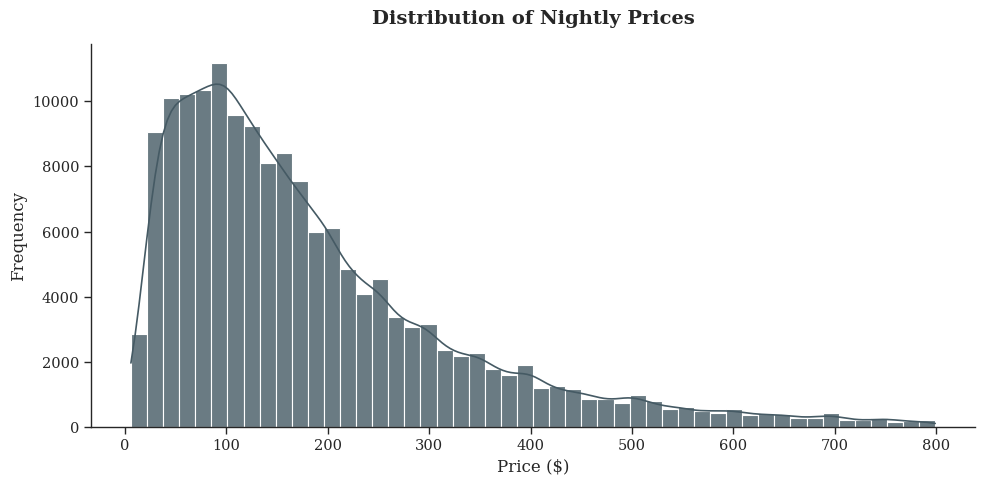

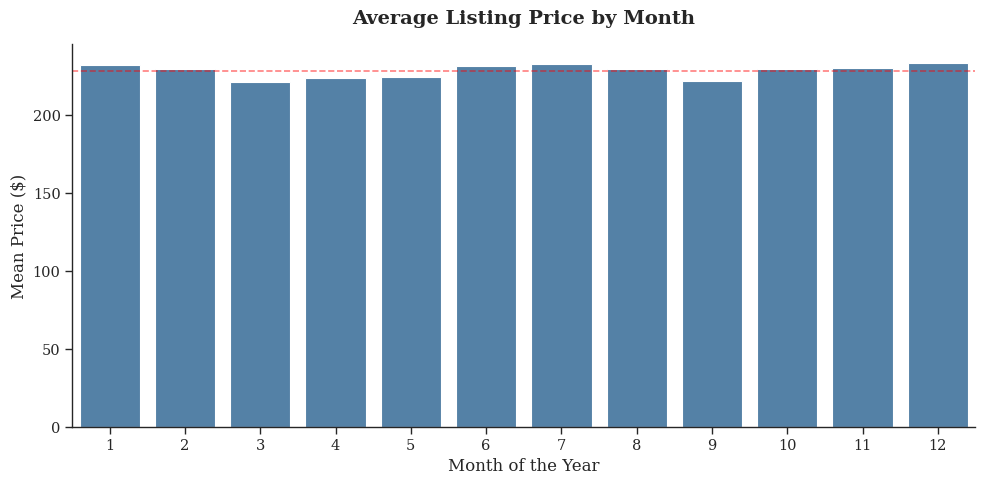

/root/.ipykernel/1641/command-4701516816291300-162713204:38: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = pdf_viz[available_cols].corr()


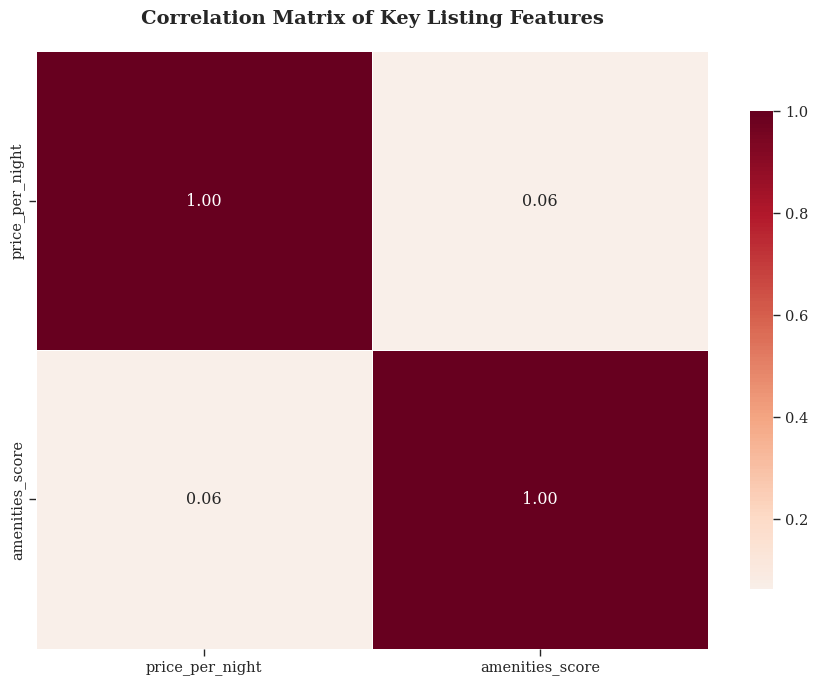

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_context("paper", font_scale=1.2)  
sns.set_style("ticks") 

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.spines.top'] = False   
plt.rcParams['axes.spines.right'] = False 

#Prepare Data (10% Sample)
print("Sampling 10% of data for visualization...")
pdf_viz = df_final_usd.sample(fraction=0.1, seed=42).toPandas()

#Price Distribution 
plt.figure(figsize=(10, 5))
sns.histplot(pdf_viz[pdf_viz['price_per_night'] < 800]['price_per_night'], 
             bins=50, kde=True, color='#455A64', edgecolor='white', alpha=0.8)
plt.title("Distribution of Nightly Prices", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
monthly_price = pdf_viz.groupby('month')['price_per_night'].mean().reset_index()
sns.barplot(x='month', y='price_per_night', data=monthly_price, color='steelblue')
plt.title("Average Listing Price by Month", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month of the Year", fontsize=12)
plt.ylabel("Mean Price ($)", fontsize=12)
plt.axhline(monthly_price['price_per_night'].mean(), color='red', linestyle='--', alpha=0.5, label='Annual Mean') 
plt.tight_layout()
plt.show()
# Feature Correlations 
plt.figure(figsize=(9, 7))
cols_to_corr = ['price_per_night', 'guests', 'amenities_score', 'ratings', 'property_number_of_reviews']
available_cols = [c for c in cols_to_corr if c in pdf_viz.columns]
corr_matrix = pdf_viz[available_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Key Listing Features", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

##**Train-Test split**

In [0]:
from pyspark.sql.functions import col, when, trim, lower, avg
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml.feature import Imputer

# Context Feature: Price Ratio (Price vs City Average)
market_stats = df_final_usd.groupBy("city", "month").agg(avg("price_per_night").alias("avg_market_price"))
df_enhanced = df_final_usd.join(market_stats, on=["city", "month"], how="left")

df_enhanced = (
    df_enhanced
    .withColumn("price_ratio", col("price_per_night") / col("avg_market_price"))
    .na.fill(1.0, subset=["price_ratio"])
)

# Casting & Binary Features
data_prep = (
    df_enhanced
    .withColumn("guests", col("guests").cast(DoubleType()))
    .withColumn("host_rating", col("host_rating").cast(DoubleType()))
    .withColumn("property_number_of_reviews", col("property_number_of_reviews").cast(DoubleType()))
    .withColumn("price_per_night", col("price_per_night").cast(DoubleType()))
    .withColumn("amenities_score", col("amenities_score").cast(DoubleType()))
    .withColumn("avg_salary_usd", col("avg_salary_usd").cast(DoubleType()))
    .withColumn("ratings", col("ratings").cast(DoubleType()))
    .withColumn("month", col("month").cast(IntegerType()))
    .withColumn("price_ratio", col("price_ratio").cast(DoubleType()))
    .na.fill(0, subset=["property_number_of_reviews"])
    .withColumn("is_supperhost_binary", when(trim(lower(col("is_supperhost").cast("string"))) == "true", 1).otherwise(0))
    .withColumn("is_booked", when(col("num_days") > 0, 1).otherwise(0))
)

# Split & Impute (Fit on Train, Apply to Both)
(train_raw, test_raw) = data_prep.randomSplit([0.8, 0.2], seed=42)

imputer = Imputer(
    inputCols=["host_rating", "avg_salary_usd", "ratings"],
    outputCols=["host_rating", "avg_salary_usd", "ratings"]
).setStrategy("median")

imputer_model = imputer.fit(train_raw)
train_data = imputer_model.transform(train_raw)
test_data = imputer_model.transform(test_raw)

# Create Non-Zero Subset (for Regressor)
train_nonzero = train_data.filter(col("num_days") > 0)

train_data.cache()
count_train = train_data.count()  
train_nonzero.cache()
count_nonzero = train_nonzero.count() 



🏃 View run thoughtful-newt-244 at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/511058141671037/runs/4aedf9d01ef340768fc6374460d470f1
🧪 View experiment at: https://adb-983293358114278.18.azuredatabricks.net/ml/experiments/511058141671037


##**Training and evaluating both models**

In [0]:
import time
import mlflow
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, lit

mlflow.autolog(disable=True)

if "amenities_count" in train_data.columns and "amenities_score" not in train_data.columns:
    train_data = train_data.withColumnRenamed("amenities_count", "amenities_score")
    test_data = test_data.withColumnRenamed("amenities_count", "amenities_score")
    train_nonzero = train_nonzero.withColumnRenamed("amenities_count", "amenities_score")

# Define Features
categorical_cols = ["city"] 
numerical_cols = ["price_per_night", "price_ratio","amenities_score", "ratings", "guests", 
                  "avg_salary_usd", "host_rating", "property_number_of_reviews", 
                  "month", "is_supperhost_binary"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep") for c in categorical_cols]
feature_cols = [f"{c}_index" for c in categorical_cols] + numerical_cols
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# PARAMETER TUNING SECTION 
PRO_ITER = 35     
PRO_DEPTH = 6       
PRO_STEPSIZE = 0.1 
PRO_BINS = 128      

# Train Model A: Classifier
print(f"Training Classifier (Iter={PRO_ITER}, Depth={PRO_DEPTH})...")
start_time = time.time()

gbt_classifier = GBTClassifier(featuresCol="features", labelCol="is_booked", 
                               maxIter=PRO_ITER, maxDepth=PRO_DEPTH, 
                               stepSize=PRO_STEPSIZE, maxBins=PRO_BINS, seed=42)

pipeline_cls = Pipeline(stages=indexers + [assembler, gbt_classifier])
model_cls = pipeline_cls.fit(train_data)
print(f"Classifier Trained in {(time.time() - start_time)/60:.1f} minutes.")

# Train Model B: Regressor
print("\n" + "="*60)
print(f"Training Regressor (Iter={PRO_ITER}, Depth={PRO_DEPTH})...")
start_time = time.time()

gbt_regressor = GBTRegressor(featuresCol="features", labelCol="num_days", 
                             maxIter=PRO_ITER, maxDepth=PRO_DEPTH, 
                             stepSize=PRO_STEPSIZE, maxBins=PRO_BINS, seed=42)

pipeline_reg = Pipeline(stages=indexers + [assembler, gbt_regressor])
model_reg = pipeline_reg.fit(train_nonzero)
print(f" Regressor Trained in {(time.time() - start_time)/60:.1f} minutes.")

# ADVANCED EVALUATION (METRICS)
print("\n" + "="*60)
print("🔍 PHASE 1: TECHNICAL METRICS")
print("="*60)

# Classifier Metrics
preds_cls = model_cls.transform(test_data)

# AUC (Discrimination ability)
bc_eval = BinaryClassificationEvaluator(labelCol="is_booked", rawPredictionCol="rawPrediction")
auc = bc_eval.setMetricName("areaUnderROC").evaluate(preds_cls)
pr_auc = bc_eval.setMetricName("areaUnderPR").evaluate(preds_cls)

# Precision & Recall (Accuracy balance)
mc_eval = MulticlassClassificationEvaluator(labelCol="is_booked", predictionCol="prediction")
precision = mc_eval.setMetricName("weightedPrecision").evaluate(preds_cls)
recall = mc_eval.setMetricName("weightedRecall").evaluate(preds_cls)

print(f" CLASSIFIER SCORECARD:")
print(f"   • AUC (ROC):        {auc:.4f}  (>0.7 is Good)")
print(f"   • Precision:        {precision:.4f}")
print(f"   • Recall:           {recall:.4f}")

# Regressor Metrics 
test_nonzero = test_data.filter(col("num_days") > 0)
preds_reg = model_reg.transform(test_nonzero)

reg_eval = RegressionEvaluator(labelCol="num_days", predictionCol="prediction")
rmse = reg_eval.setMetricName("rmse").evaluate(preds_reg)
mae = reg_eval.setMetricName("mae").evaluate(preds_reg)
r2 = reg_eval.setMetricName("r2").evaluate(preds_reg)

print(f"\nREGRESSOR SCORECARD:")
print(f"   • RMSE (Error):     {rmse:.2f} days")
print(f"   • MAE (Avg Miss):   {mae:.2f} days")
print(f"   • R2 (Var Exp):     {r2:.4f}")

#STRATEGIC EVALUATION (FEATURE IMPORTANCE)
print("PHASE 2: MODEL LOGIC CHECK (Feature Importance)")

def extract_and_print_importance(pipeline_model, feature_names, model_name):
    # Extract the GBT model from the last stage of the pipeline
    model = pipeline_model.stages[-1]
    importances = model.featureImportances.toArray()
    
    #Create a sorted list
    feat_data = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)
    
    print(f"\n👉 {model_name} Top Drivers:")
    for name, score in feat_data[:10]: 
        print(f"   • {name:<30}: {score:.1%}")

extract_and_print_importance(model_cls, feature_cols, "Classifier (Will it book?)")
extract_and_print_importance(model_reg, feature_cols, "Regressor (How long?)")



Training Classifier (Iter=35, Depth=6)...
Classifier Trained in 7.2 minutes.

Training Regressor (Iter=35, Depth=6)...
 Regressor Trained in 5.8 minutes.

🔍 PHASE 1: TECHNICAL METRICS
 CLASSIFIER SCORECARD:
   • AUC (ROC):        0.8390  (>0.7 is Good)
   • Precision:        0.8530
   • Recall:           0.8710

REGRESSOR SCORECARD:
   • RMSE (Error):     1.91 days
   • MAE (Avg Miss):   0.86 days
   • R2 (Var Exp):     0.6570
PHASE 2: MODEL LOGIC CHECK (Feature Importance)

👉 Classifier (Will it book?) Top Drivers:
   • month                         : 42.9%
   • city_index                    : 28.3%
   • property_number_of_reviews    : 19.5%
   • price_ratio                   : 2.0%
   • ratings                       : 1.8%
   • guests                        : 1.7%
   • price_per_night               : 1.3%
   • host_rating                   : 1.1%
   • amenities_score               : 0.6%
   • avg_salary_usd                : 0.6%

👉 Regressor (How long?) Top Drivers:
   • month       

##**Iterative function to find the best price**

In [0]:

import holidays
import calendar
from datetime import date
import pandas as pd
import numpy as np
import builtins 
import math
from pyspark.sql.functions import col

def optimize_pricing_exponential(user_features, target_months, target_year, price_options, 
                                 country_code, model_cls, model_reg, 
                                 occupancy_ratio, event_lookup, 
                                 target_peak_price,
                                 event_impact=0.002): 

    print(f"Running Exponential Optimization (Target Peak: ${target_peak_price})...")

    # Sanitize Inputs 
    clean_features = {}
    if hasattr(user_features, "asDict"): user_input = user_features.asDict()
    else: user_input = dict(user_features)
    
    # Clean keys and ensure numbers are numbers
    for k, v in user_input.items():
        if str(k).endswith("_index") or k in ["features", "prediction", "probability", "rawPrediction"]: continue
        if isinstance(v, (np.floating, float)): clean_features[k] = float(v)
        elif isinstance(v, (np.integer, int)): clean_features[k] = int(v)
        else: clean_features[k] = str(v)
            
    # Ensure City is clean (UPPERCASE) for Event Lookup
    if 'city' in clean_features:
        clean_features['city'] = str(clean_features['city']).upper().strip()
    target_city = clean_features.get("city", "")

    # Ensure binary superhost exists
    if "is_supperhost_binary" not in clean_features:
        raw_val = str(user_input.get("is_supperhost", "false")).lower()
        clean_features["is_supperhost_binary"] = 1 if raw_val == "true" else 0

    # Build Scenarios
    rows = []
    idx = 0
    for m in target_months:
        for p in price_options:
            r = clean_features.copy()
            r['month'] = int(m)
            r['price_per_night'] = float(p)
            
            
            # The model needs this column. We use target_peak_price as the baseline.
            r['price_ratio'] = float(p / target_peak_price)
            
            r['scenario_id'] = int(idx)
            rows.append(r)
            idx += 1
            
    pdf = pd.DataFrame(rows)
    sdf = spark.createDataFrame(pdf)
    
    # Run Models & COLLECT
    res_cls = model_cls.transform(sdf).select("scenario_id", "probability").collect()
    res_reg = model_reg.transform(sdf).select("scenario_id", "month", "price_per_night", "prediction").collect()
    
    # Optimization Logic
    probs_map = {}
    for r in res_cls:
        try: probs_map[r['scenario_id']] = float(r['probability'][1])
        except: probs_map[r['scenario_id']] = 0.0
            
    best_months = {} 
    
    # Pre-calculate decay constant K
    k_decay = 1.0 / target_peak_price
    
    for r in res_reg:
        sid = r['scenario_id']
        m = r['month']
        price = r['price_per_night']
        days_pred = float(r['prediction'])
        prob = probs_map.get(sid, 0.0)
        
        # Exponential Decay Logic (Pure)
        decay_factor = math.exp(-k_decay * price) * 2.718 
        adjusted_prob = prob * decay_factor
        adjusted_prob = builtins.min(adjusted_prob, 1.0)
        
        exp_days = adjusted_prob * days_pred
        exp_rev = price * exp_days
        
        if m not in best_months or exp_rev > best_months[m]['rev']:
            best_months[m] = {
                'month': m,
                'base_price': price,
                'base_days': exp_days,
                'rev': exp_rev,
                'decay_impact': f"{builtins.round(decay_factor, 2)}x"
            }
            
    # Finalize Output
    holidays_country = holidays.country_holidays(country_code, years=target_year)
    final_data = []
    
    for m in sorted(best_months.keys()):
        data = best_months[m]
        
        # Event Boost
        evt_count = event_lookup.get((target_city, target_year, m), 0)
        boost_mult = 1.0 + builtins.min(evt_count * event_impact, 0.5)
        
        final_base_price = data['base_price'] * boost_mult
        final_revenue = final_base_price * data['base_days']
        
        # Splits
        days_in_month = calendar.monthrange(target_year, m)[1]
        cap_prem = 0; cap_norm = 0
        for d in range(1, days_in_month + 1):
            dt = date(target_year, m, d)
            if dt.weekday() >= 4 or dt in holidays_country: cap_prem += 1
            else: cap_norm += 1
            
        denom_days = cap_norm + (occupancy_ratio * cap_prem)
        rate_norm = (data['base_days'] / denom_days) if denom_days > 0 else 0
        
        booked_norm = builtins.min(rate_norm, 1.0) * cap_norm
        booked_prem = builtins.min(rate_norm * occupancy_ratio, 1.0) * cap_prem
        
        denom_price = booked_norm + (occupancy_ratio * booked_prem)
        p_norm = (final_revenue / denom_price) if denom_price > 0 else final_base_price
        p_prem = p_norm * occupancy_ratio
        
        final_data.append({
            "Month": m,
            "Events": evt_count,
            "Target_Peak": f"${target_peak_price}",
            "Weekday_Price": builtins.round(p_norm, 2),
            "Weekend_Price": builtins.round(p_prem, 2),
            "Est_Occupancy_%": builtins.round(((booked_norm+booked_prem)/days_in_month)*100, 1),
            "Proj_Revenue": builtins.round(final_revenue, 2)
        })
        
    return pd.DataFrame(final_data)



In [0]:
# SYSTEM CONFIGURATION

#Create fast Salary Lookup Dictionary
#This allows us to instantly find the economic data for the chosen city
salary_lookup = df_final_usd.select("city", "avg_salary_usd") \
    .distinct().toPandas().set_index("city")["avg_salary_usd"].to_dict()

#Define Technical Constants
#These are fixed physics of the model that the user shouldn't worry about
SYSTEM_CONSTANTS = {
    "event_impact": 0.002,      # How much events boost price sensitivity
    "target_year": 2026         # Default prediction year
}



In [0]:
import numpy as np
# USER INTERFACE: ENTER PROPERTY DETAILS
USER_INPUT = {
    #Property Details
    "city": "AMSTERDAM",          
    "country_code": "NL",         
    "guests": 4,                  # Max capacity
    "amenities_count": 25,        # Actual number of amenities (e.g. Wifi, Pool, AC = 3)
    "ratings": 4.85,              
    "host_rating": 4.9,           
    "num_reviews": 45,            
    "is_superhost": True,         
    #Strategy Settings
    "target_peak_price": 125,     # The "Ideal" price you aim for (Center of gravity)
    "months_to_predict": [6, 7, 8], 
    #Price Search Range
    "price_min": 50,             
    "price_max": 200,             
    "price_step": 5              # Step size (smaller = more precision, slower)
}

# EXECUTION ENGINE 
#Auto-Fill Salary
clean_city = str(USER_INPUT["city"]).upper().strip()
salary = salary_lookup.get(clean_city, 3000) # Default $3,000 if unknown

#Convert Amenities Count -> Model Score (Log Transformation)
calc_amenities_score = np.log1p(USER_INPUT["amenities_count"])

#Generate Price Options based on User Range
price_options = list(range(
    USER_INPUT["price_min"], 
    USER_INPUT["price_max"], 
    USER_INPUT["price_step"]))

#Prepare Feature Dictionary
feature_payload = {
    "city": clean_city,
    "amenities_score": calc_amenities_score, 
    "ratings": USER_INPUT["ratings"],
    "guests": USER_INPUT["guests"],
    "host_rating": USER_INPUT["host_rating"],
    "property_number_of_reviews": USER_INPUT["num_reviews"],
    "is_supperhost_binary": 1 if USER_INPUT["is_superhost"] else 0,
    "avg_salary_usd": salary
}

print(f"Analyzing Property in {clean_city} (Avg Salary: ${salary:,.0f})...")
print(f"Amenities: {USER_INPUT['amenities_count']} -> Score: {calc_amenities_score:.2f}")
print(f"Testing {len(price_options)} price points per month...")

#Run Optimization
final_df = optimize_pricing_exponential(
    user_features=feature_payload, 
    target_months=USER_INPUT["months_to_predict"], 
    target_year=SYSTEM_CONSTANTS["target_year"], 
    price_options=price_options, 
    country_code=USER_INPUT["country_code"],
    model_cls=model_cls, 
    model_reg=model_reg,
    occupancy_ratio=OCCUPANCY_RATIO,  # <--- Uses your global constant
    event_lookup=EVENT_LOOKUP, 
    target_peak_price=USER_INPUT["target_peak_price"],
    event_impact=SYSTEM_CONSTANTS["event_impact"]
)

#Display Results
if not final_df.empty:
    print(f"\n EST. TOTAL REVENUE: ${final_df['Proj_Revenue'].sum():,.2f}")
    display(final_df)
else:
    print("No results found. Try adjusting the input parameters.")

Analyzing Property in AMSTERDAM (Avg Salary: $4,888)...
Amenities: 25 -> Score: 3.26
Testing 30 price points per month...
Running Exponential Optimization (Target Peak: $125)...

 EST. TOTAL REVENUE: $339.91


Month,Events,Target_Peak,Weekday_Price,Weekend_Price,Est_Occupancy_%,Proj_Revenue
6,104,$125,166.25,187.04,3.0,157.81
7,30,$125,125.47,141.16,3.1,129.34
8,4,$125,185.41,208.59,0.9,52.76
